In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
df = pd.read_csv('Ratio.csv')
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.843663
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.783431
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.777522
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.825769
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.889904


<Axes: >

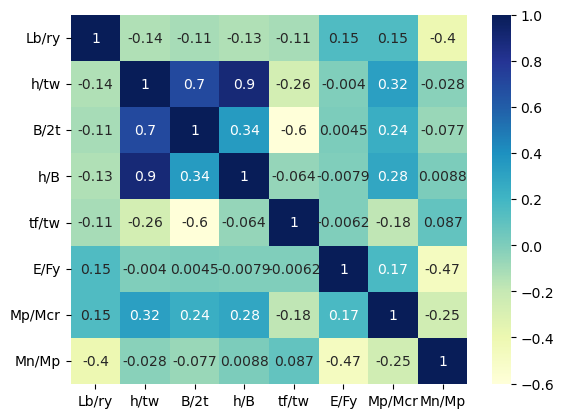

In [3]:
sns.heatmap(df.corr(numeric_only=True), cmap="YlGnBu", annot=True)

In [4]:
df.describe()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
count,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000
mean,97.366596,34.963695,5.634730,1.853852,1.653545,248.937214,1.624280,0.726006
std,37.083167,14.070018,1.363515,0.583968,0.116217,40.796326,0.948242,0.192763
min,29.629630,10.100775,3.115942,0.885256,1.380000,208.279468,0.232590,0.203974
25%,68.441065,20.685393,4.491525,1.588288,1.597315,208.279468,0.905141,0.605143
50%,93.655589,36.729167,5.434783,1.911429,1.640351,208.279468,1.416495,0.747639
75%,120.786517,45.524476,6.826087,2.216407,1.730496,289.779767,2.146375,0.905529
max,247.734139,61.420000,7.971014,2.791818,1.903614,289.779767,5.694176,1.009362


(0.0, 1.0)

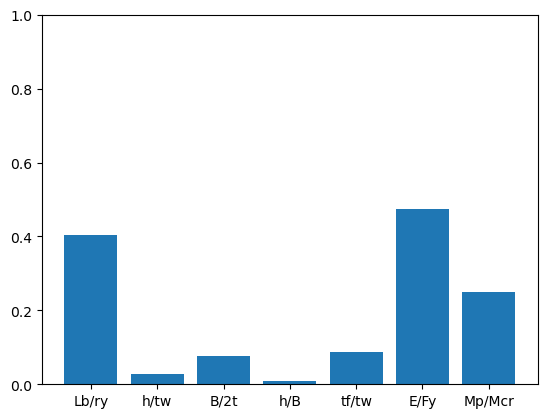

In [5]:
C = df.corr(numeric_only=True)['Mn/Mp'][:-1]
plt.bar(C.index, np.abs(C.values))
plt.ylim([0, 1])

In [6]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=123)

In [8]:
def evaluate_pipeline(pipeline, threshold=0.1):
    pipeline_train_prd = pipeline.predict(X_train)
    pipeline_train_outliers = np.abs(pipeline_train_prd - y_train) > threshold
    mod_pipeline_train_prd = pipeline_train_prd[~ pipeline_train_outliers]
    mod_y_train = y_train[~ pipeline_train_outliers]
    pipeline_train_mse = mean_squared_error(mod_pipeline_train_prd, mod_y_train)
    pipeline_train_mae = mean_absolute_error(mod_pipeline_train_prd, mod_y_train)
    pipeline_train_r2_score = r2_score(mod_pipeline_train_prd, mod_y_train)
    
    pipeline_test_prd = pipeline.predict(X_test)
    pipeline_test_outliers = np.abs(pipeline_test_prd - y_test) > threshold
    mod_pipeline_test_prd = pipeline_test_prd[~ pipeline_test_outliers]
    mod_y_test = y_test[~ pipeline_test_outliers]
    pipeline_test_mse = mean_squared_error(mod_pipeline_test_prd, mod_y_test)
    pipeline_test_mae = mean_absolute_error(mod_pipeline_test_prd, mod_y_test)
    pipeline_test_r2_score = r2_score(mod_pipeline_test_prd, mod_y_test)
    
    pipeline_full_prd = pipeline.predict(X_full)
    pipeline_full_outliers = np.abs(pipeline_full_prd - y_full) > threshold
    mod_pipeline_full_prd = pipeline_full_prd[~ pipeline_full_outliers]
    mod_y_full = y_full[~ pipeline_full_outliers]
    pipeline_full_mse = mean_squared_error(mod_pipeline_full_prd, mod_y_full)
    pipeline_full_mae = mean_absolute_error(mod_pipeline_full_prd, mod_y_full)
    pipeline_full_r2_score = r2_score(mod_pipeline_full_prd, mod_y_full)
    
    metrics = {
        'y_train': mod_y_train,
        'y_test' : mod_y_test,
        'train_mse': pipeline_train_mse,
        'train_mae': pipeline_train_mae,
        'train_r2': pipeline_train_r2_score,
        'test_mse': pipeline_test_mse,
        'test_mae': pipeline_test_mae,
        'test_r2': pipeline_test_r2_score,
        'full_mse': pipeline_full_mse,
        'full_mae': pipeline_full_mae,
        'full_r2': pipeline_full_r2_score,
        'train_predictions': mod_pipeline_train_prd,
        'test_predictions': mod_pipeline_test_prd
    }

    return metrics

def plot_accuracy(pipeline_metrics, title):
    y_train = pipeline_metrics['y_train']
    y_test = pipeline_metrics['y_test']
    
    pipeline_train_prd = pipeline_metrics['train_predictions']
    pipeline_test_prd = pipeline_metrics['test_predictions']
    pipeline_train_r2_score = pipeline_metrics['train_r2']
    pipeline_test_r2_score = pipeline_metrics['test_r2']
    pipeline_full_r2_score = pipeline_metrics['full_r2']
    
    
    fig_train, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'R2={pipeline_train_r2_score:.5f}')
    axes.plot(y_train, pipeline_train_prd, 'bo', alpha=0.5, markeredgewidth=0.1, label='Train data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_train.savefig(f'{title}-train.svg')

    fig_test, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'R2={pipeline_test_r2_score:.5f}')
    axes.plot(y_test, pipeline_test_prd, 'ro', alpha=0.5, markeredgewidth=0.1, label='Test data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_test.savefig(f'{title}-test.svg')

    fig_full, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'R2={pipeline_full_r2_score:.5f}')
    axes.plot(y_train, pipeline_train_prd, 'bo', alpha=0.5, markeredgewidth=0.1, label='Train data');
    axes.plot(y_test, pipeline_test_prd, 'ro', alpha=0.5, markeredgewidth=0.1, label='Test data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_test.savefig(f'{title}-full.svg')

def plot_cross_validation(cv_result):
    mean_mse = cv_result['mean_test_score']
    params_df = pd.DataFrame(cv_result['params'].tolist())
    heatmap_data = params_df.copy()
    heatmap_data['mean_r2'] = mean_mse

    param_x = heatmap_data.columns[0]
    param_y = heatmap_data.columns[1]

    pivot_table = heatmap_data.pivot_table(values='mean_r2', index=param_y, columns=param_x)

    sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".6f", linewidths=.5, cbar_kws={'label': 'R2'})
    plt.title('Mean R2 across Hyperparameter Combinations')
    plt.xlabel(param_x)
    plt.ylabel(param_y)

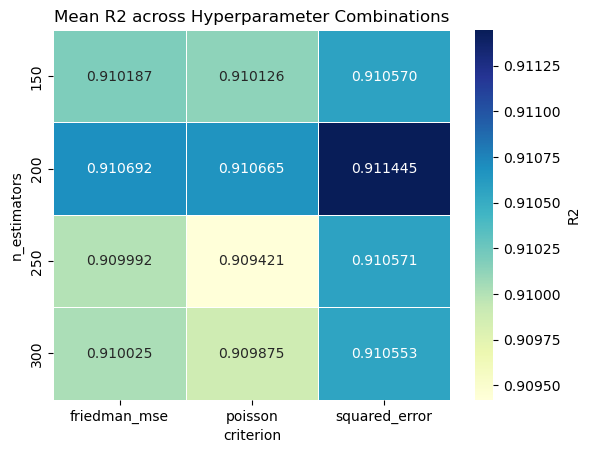

In [9]:
rf_params = {
    'criterion' : ['squared_error', 'friedman_mse', 'poisson'],
    'n_estimators' : [150, 200, 250, 300],
}

rf_cv = GridSearchCV(RandomForestRegressor(random_state=42), rf_params)
rf_cv.fit(X_train, y_train)
rf_best = rf_cv.best_estimator_
rf_metrics = evaluate_pipeline(rf_best)

rf_cv_result = pd.DataFrame(rf_cv.cv_results_)
plot_cross_validation(rf_cv_result)
plt.savefig('random-forest-hyperparameters.svg')

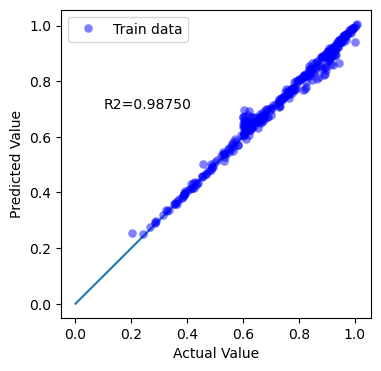

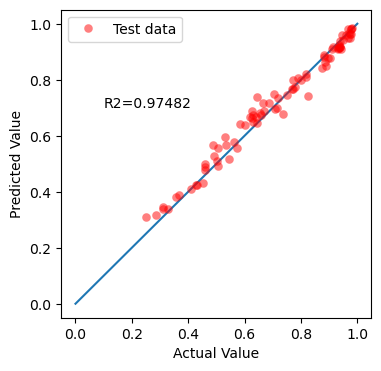

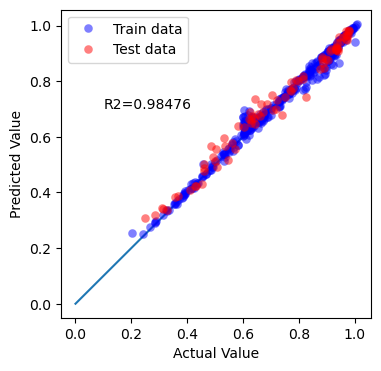

In [10]:
rf_metrics = evaluate_pipeline(rf_best)
plot_accuracy(rf_metrics, 'random-forest')

{'n_estimators': 300, 'subsample': 0.7}


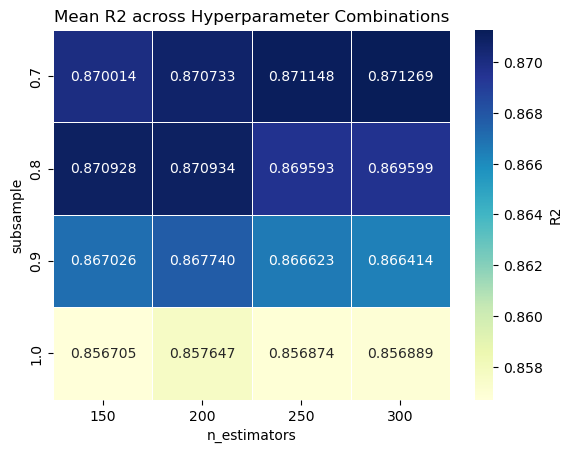

In [11]:
gb_params = {
    'subsample' : [0.7, 0.8, 0.9, 1.0],
    'n_estimators' : [150, 200, 250, 300],
}

gb_cv = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params)
gb_cv.fit(X_train, y_train)
gb_best = gb_cv.best_estimator_

print(gb_cv.best_params_)

gb_cv_result = pd.DataFrame(gb_cv.cv_results_)
plot_cross_validation(gb_cv_result)
plt.savefig('gradient-boosting-hyperparameters.svg')

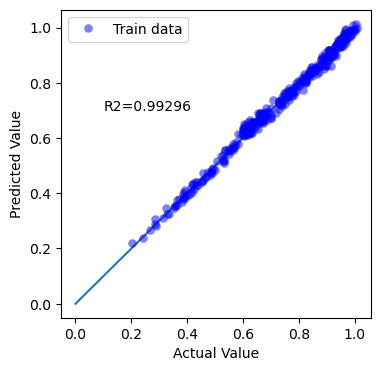

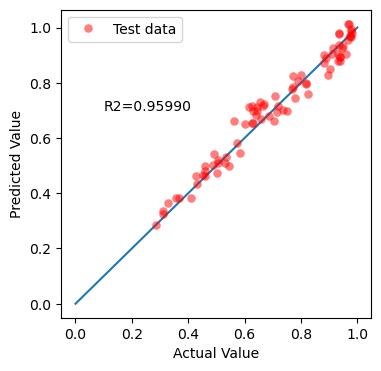

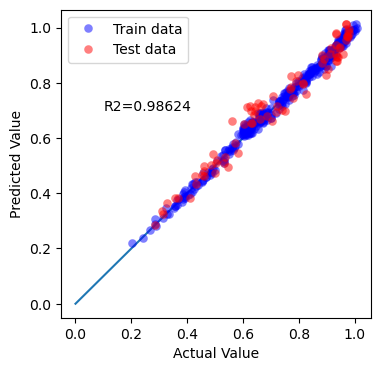

In [12]:
gb_metrics = evaluate_pipeline(gb_best)
plot_accuracy(gb_metrics, 'gradient-boosting')

In [13]:
from sklearn.svm import LinearSVR, SVR
from scipy.stats import loguniform, uniform
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

kernels = ['linear', 'rbf', 'poly']
svr_params = {
    'svr__C': loguniform(1e-1, 1e2),
    'svr__epsilon': uniform(0.01, 0.1)
}

svr_metrics = dict()

for kernel in ['linear', 'rbf', 'poly']:
    if kernel == 'linear':
        base_model = SVR(kernel=kernel)
        base_params = svr_params
    else:
        base_model = SVR(kernel=kernel)
        base_params = {**svr_params, 'svr__gamma': loguniform(1e-3, 1e3)}

    svr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', base_model)
    ])

    svr_cv = RandomizedSearchCV(svr_pipeline, base_params, n_iter=10, random_state=100, n_jobs=-1)
    svr_cv.fit(X_train, y_train)
    
    svr_best = svr_cv.best_estimator_
    svr_cv_result = pd.DataFrame(svr_cv.cv_results_)
    print(svr_cv.best_params_)

    svr_metrics[kernel] = evaluate_pipeline(svr_best)

{'svr__C': np.float64(0.4561340339602273), 'svr__epsilon': np.float64(0.10786237847073697)}
{'svr__C': np.float64(4.2679058013626765), 'svr__epsilon': np.float64(0.037836938509379615), 'svr__gamma': np.float64(0.3524565164435525)}
{'svr__C': np.float64(86.27229557752123), 'svr__epsilon': np.float64(0.09116831490893233), 'svr__gamma': np.float64(0.01075588317270133)}


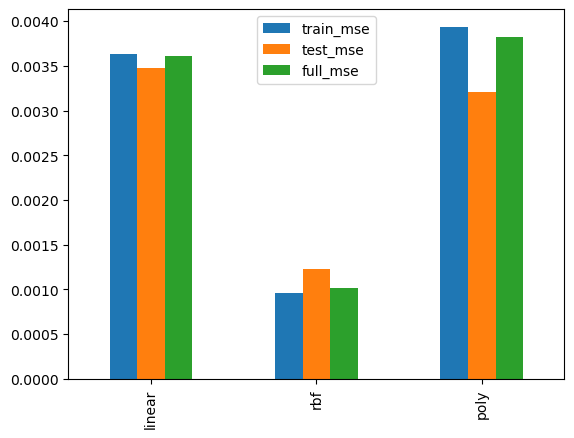

In [14]:
pd.DataFrame(svr_metrics).filter(regex='_mse', axis=0).transpose().plot.bar()
plt.savefig('svr-kernel-mse.svg')

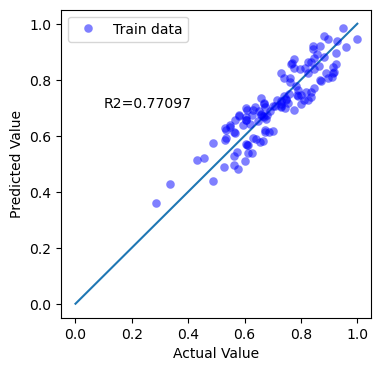

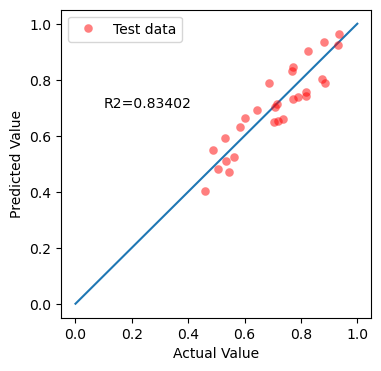

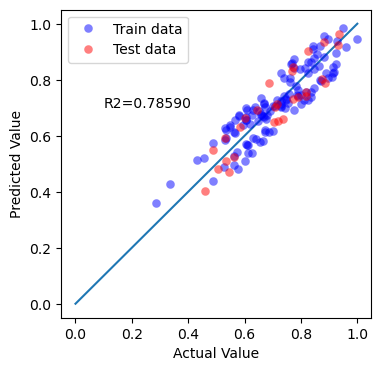

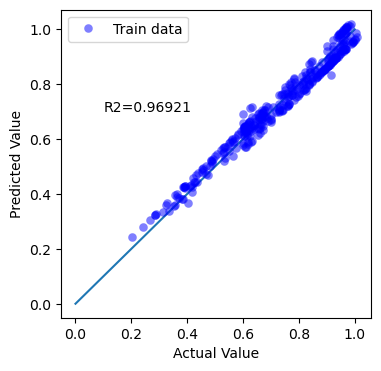

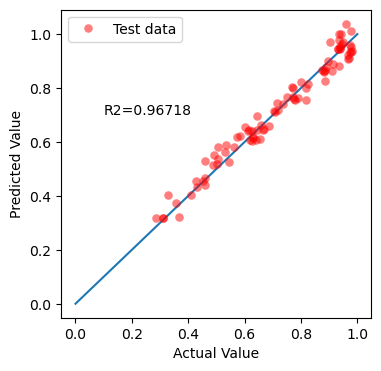

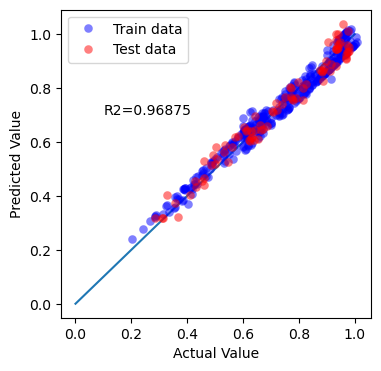

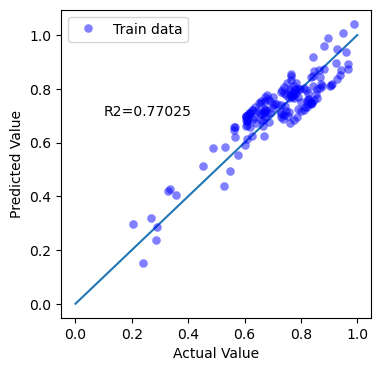

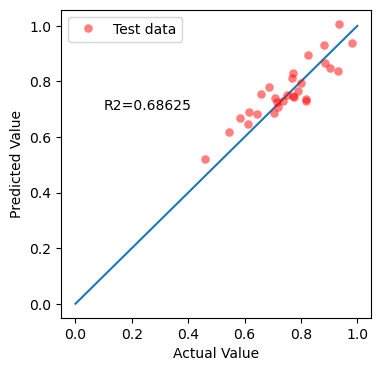

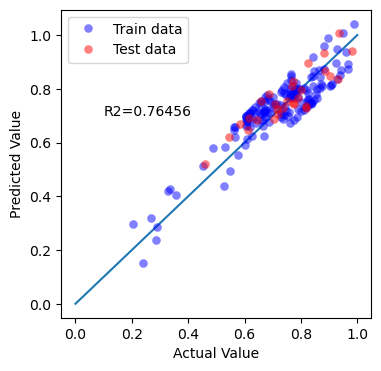

In [15]:
for kernel in kernels:
    plot_accuracy(svr_metrics[kernel], f'SVR-{kernel}')

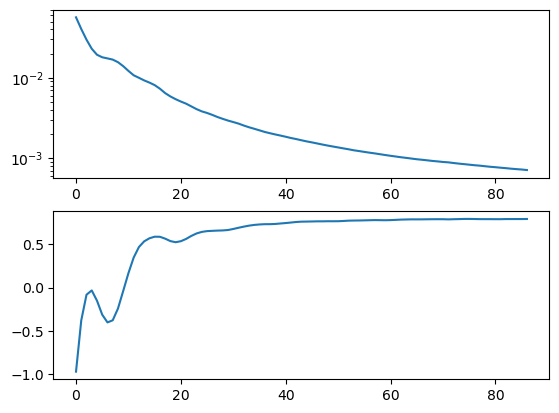

In [16]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

nn_params = {
    'mlp__hidden_layer_sizes' : [(16, 16, 16, 16), (32, 32, 32, 32), (64, 64)],
    'mlp__activation' : ['relu', 'tanh']
}

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=500))
])

nn_cv = GridSearchCV(nn_pipeline, nn_params)
nn_cv.fit(X_train, y_train)

nn_best = nn_cv.best_estimator_
nn_cv_result = pd.DataFrame(nn_cv.cv_results_)

plt.subplot(2, 1, 1)
plt.semilogy(nn_best['mlp'].loss_curve_)
plt.subplot(2, 1, 2)
plt.plot(nn_best['mlp'].validation_scores_)
plt.savefig('mlp.svg')

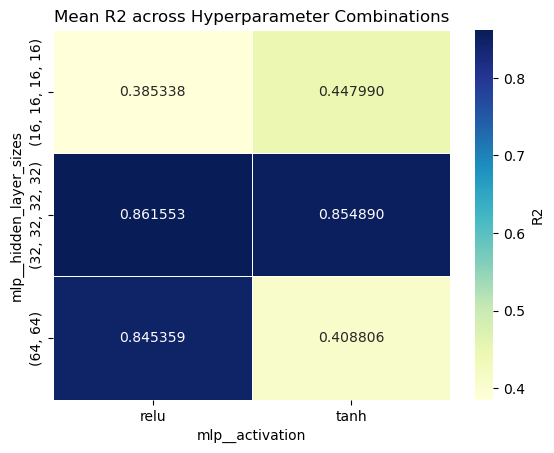

In [17]:
plot_cross_validation(nn_cv_result)
plt.savefig('mlp-hyperparameters.svg')

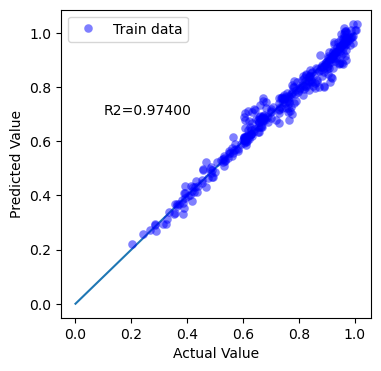

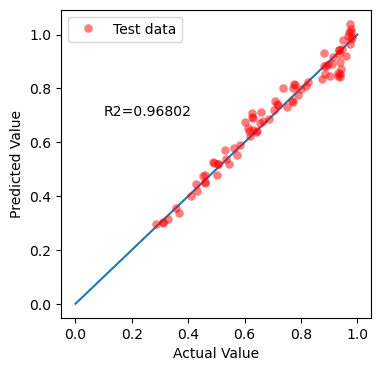

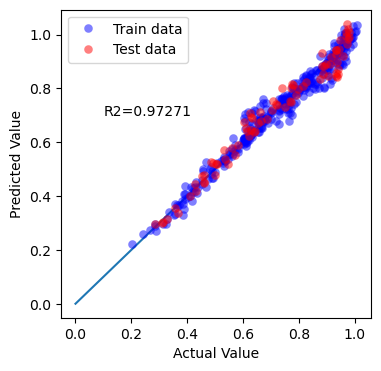

In [23]:
nn_metrics = evaluate_pipeline(nn_best, 0.1)
plot_accuracy(nn_metrics, 'mlp-metrics')

/home/shantanurahman/.local/share/mamba/envs/ibeam-ml/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


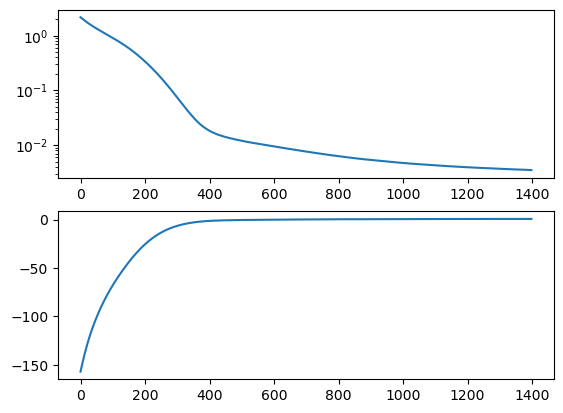

In [19]:
small_nn_params = {
    'mlp__hidden_layer_sizes' : [(x,) for x in range(1, 15)],
    'mlp__activation' : ['relu', 'tanh', 'logistic']
}

small_nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=2000))
])

small_nn_cv = GridSearchCV(small_nn_pipeline, small_nn_params)
small_nn_cv.fit(X_train, y_train)

small_nn_best = small_nn_cv.best_estimator_
small_nn_cv_result = pd.DataFrame(small_nn_cv.cv_results_)

plt.subplot(2, 1, 1)
plt.semilogy(small_nn_best['mlp'].loss_curve_)
plt.subplot(2, 1, 2)
plt.plot(small_nn_best['mlp'].validation_scores_)
plt.savefig('small-nn.svg')

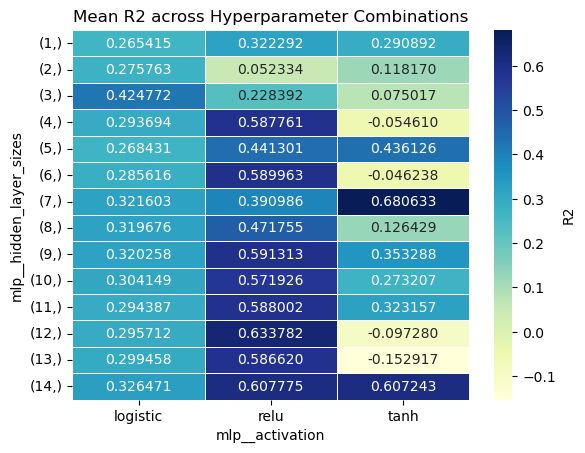

In [20]:
plot_cross_validation(small_nn_cv_result)
plt.savefig('small-nn-hyperparameters.svg')

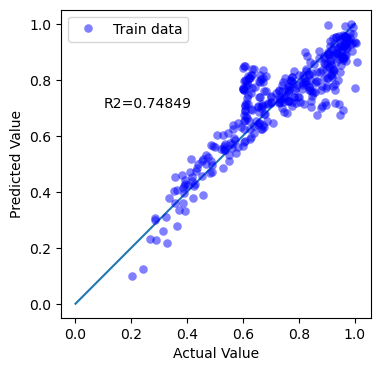

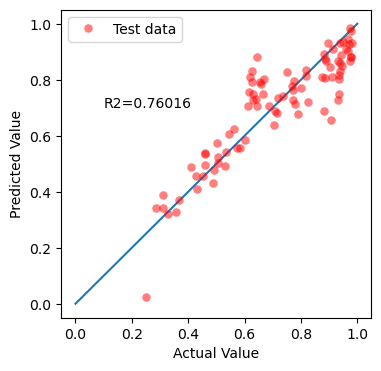

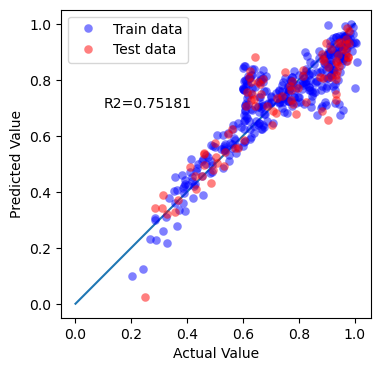

In [21]:
small_nn_metrics = evaluate_pipeline(small_nn_best, 100.0)
plot_accuracy(small_nn_metrics, 'small-nn-metrics')